
# 🛠️ Drone Parts Segmentation — **Transfer Learning (VGG16-UNet)**

이 노트북은 **semantic-drone-dataset** 템플릿을 기반으로, **드론 부품** 세그멘테이션에 맞춰 전이학습(fine-tuning)하도록 구성되어 있습니다.

**주요 기능**
- 데이터셋: RGB 마스크 → 클래스 ID 매핑
- 증강: Albumentations (버전 안전 파라미터)
- 모델: `segmentation_models_pytorch`의 U-Net (VGG16-BN encoder, ImageNet pretrained)
- 손실: CrossEntropy + Dice (클래스 가중치 지원)
- 스케줄러: CosineAnnealingWarmRestarts (Warm restarts)
- 디바이스: CUDA, **MPS(Apple Silicon)**, CPU 자동 선택
- 로깅: Loss/IoU/Dice 출력, 베스트 모델 저장, 시각화

> **데이터 구조**
```
data_root/
  train/
    images/*.jpg|png
    masks/*.png|jpg|jpeg    # RGB mask (아래 색-클래스 매핑 사용)
  val/
    images/*.jpg|png
    masks/*.png|jpg|jpeg
```


In [1]:

# (선택) 필요 시 설치 — 로컬/Colab 환경에 맞게 조정하세요.
# %pip install -U pip
# %pip install segmentation-models-pytorch albumentations opencv-python tqdm matplotlib


## 1. 환경 설정 및 경로 지정
모델 학습 및 평가에 필요한 경로와 하드웨어 환경을 설정
- **DATA_ROOT** : 데이터셋 폴더 경로  
- **OUT_DIR** : 학습 결과(모델, 로그, 시각화)를 저장할 폴더  
- **IMG_SIZE** : 입력 이미지 크기  
- CUDA 사용 가능 시 GPU, 아니면 MPS/CPU를 자동 선택

In [1]:

import os, random, numpy as np, torch

# ==== 경로 설정 ====
DATA_ROOT = "./data/raw"   
OUT_DIR   = "./outputs"            # 체크포인트 및 시각화 저장 폴더
IMG_SIZE  = 512                    # 입력 크기 (메모리 여유 시 576/640 시도 가능)

os.makedirs(OUT_DIR, exist_ok=True)

# ==== 디바이스 선택 (CUDA > MPS > CPU) ====
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")
DEVICE


device(type='mps')

## 2. 실험 재현성을 위한 시드 고정
모델 학습 결과가 실행마다 달라지지 않도록  
`random`, `numpy`, `torch`의 난수 발생기를 고정

In [2]:
def seed_everything(seed=42):
    import torch, numpy as np, random
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    try:
        torch.use_deterministic_algorithms(False)
    except Exception:
        pass

seed_everything(42)
print("Seeding done.")


Seeding done.


## 3. 데이터셋 구성 및 전처리 정의
드론 이미지와 대응되는 마스크를 불러와 PyTorch Dataset 형태로 구성 
- **DroneDataset** : RGB 마스크를 클래스 ID로 변환해 학습 가능한 형태로 반환  
- **get_train_transform()** : 학습용 데이터 증강 (회전, 밝기, 블러 등 다단계 설정)  
- **get_val_transform()** : 검증용 데이터 변환 (크기 조정 + 정규화만 수행)  
- 증강 강도(`level`)는 *light*, *medium*, *strong*, *extreme* 중 선택 가능

In [3]:
import os
import shutil
from pathlib import Path
import random

# ==== 설정 ====
DATA_ROOT = Path("./data/raw")
OUT_ROOT  = Path("./data")
VAL_RATIO = 0.2      # 검증 20%, train 80% (원하면 바꿔도 됨)
SEED      = 42

random.seed(SEED)

IMG_EXTS  = [".jpg", ".jpeg", ".png"]
MASK_EXTS = [".png", ".jpg", ".jpeg"]

# ==== 폴더 경로 ====
raw_img_dir  = DATA_ROOT / "images"
raw_mask_dir = DATA_ROOT / "masks"

train_img_dir = OUT_ROOT / "train" / "images"
train_mask_dir = OUT_ROOT / "train" / "masks"
val_img_dir   = OUT_ROOT / "val" / "images"
val_mask_dir  = OUT_ROOT / "val" / "masks"

for d in [train_img_dir, train_mask_dir, val_img_dir, val_mask_dir]:
    d.mkdir(parents=True, exist_ok=True)

# ==== raw에서 이미지-마스크 페어 수집 ====
pairs = []

image_files = sorted([f for f in raw_img_dir.glob("*") if f.suffix.lower() in IMG_EXTS])

for img_path in image_files:
    mask_path = None
    for ext in MASK_EXTS:
        cand = raw_mask_dir / f"{img_path.stem}{ext}"
        if cand.exists():
            mask_path = cand
            break
    if mask_path is not None:
        pairs.append((img_path, mask_path))
    else:
        print(f"⚠️ 마스크 없음, 스킵: {img_path.name}")

print(f"🔎 찾은 페어 개수: {len(pairs)}")

# ==== 섞고 train/val 나누기 ====
random.shuffle(pairs)
n_total = len(pairs)
n_val = int(n_total * VAL_RATIO)
n_train = n_total - n_val

val_pairs   = pairs[:n_val]
train_pairs = pairs[n_val:]

print(f"🚂 train: {len(train_pairs)}  /  🧪 val: {len(val_pairs)}")

# ==== 복사 함수 ====
def copy_pairs(pairs, img_out_dir, mask_out_dir):
    for img_path, mask_path in pairs:
        shutil.copy2(img_path, img_out_dir / img_path.name)
        shutil.copy2(mask_path, mask_out_dir / mask_path.name)

# ==== 실제 복사 ====
copy_pairs(train_pairs, train_img_dir, train_mask_dir)
copy_pairs(val_pairs,   val_img_dir,   val_mask_dir)

print("✅ train/val split 완료!")
print(f"   train images dir: {train_img_dir}")
print(f"   val images dir:   {val_img_dir}")

⚠️ 마스크 없음, 스킵: UAVS_1062.jpg
⚠️ 마스크 없음, 스킵: UAVS_1100.jpg
⚠️ 마스크 없음, 스킵: UAVS_286_1.jpg
⚠️ 마스크 없음, 스킵: pic_344.jpg
⚠️ 마스크 없음, 스킵: pic_380.jpg
⚠️ 마스크 없음, 스킵: pic_443.jpg
🔎 찾은 페어 개수: 561
🚂 train: 449  /  🧪 val: 112
✅ train/val split 완료!
   train images dir: data/train/images
   val images dir:   data/val/images


In [4]:

from pathlib import Path
import cv2
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset, DataLoader
import torch
import numpy as np

RGB_TO_CLASS = {
    (0, 0, 0): 0,            # background
    (255, 128, 0): 1,        # arm
    (255, 0, 0): 2,          # body
    (0, 255, 0): 3,          # camera
    (0, 0, 255): 4,          # landing_gear
    (255, 255, 0): 5,        # propeller
}

def rgb_to_class_mask(mask_rgb):
    h, w = mask_rgb.shape[:2]
    mask = np.zeros((h, w), dtype=np.uint8)
    for (r, g, b), cls_id in RGB_TO_CLASS.items():
        match = (mask_rgb[:, :, 0] == r) & (mask_rgb[:, :, 1] == g) & (mask_rgb[:, :, 2] == b)
        mask[match] = cls_id
    return mask

class DroneDataset(Dataset):
    def __init__(self, images_dir, masks_dir, transform=None):
        self.images_dir = Path(images_dir); self.masks_dir = Path(masks_dir)
        self.transform = transform
        self.image_files = sorted([f for f in self.images_dir.glob("*") if f.suffix.lower() in [".jpg",".jpeg",".png"]])
        kept = []
        for f in self.image_files:
            found = None
            for ext in [".png",".jpg",".jpeg"]:
                cand = self.masks_dir / f"{f.stem}{ext}"
                if cand.exists():
                    found = cand; break
            if found is not None:
                kept.append((f, found))
        self.pairs = kept
        print(f"✅ Dataset loaded: {len(self.pairs)} samples from {self.images_dir}")

    def __len__(self): return len(self.pairs)

    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]
        image = cv2.cvtColor(cv2.imread(str(img_path), cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB)
        mask_rgb = cv2.cvtColor(cv2.imread(str(mask_path), cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB)
        if image is None:  raise ValueError(f"Failed to read image: {img_path}")
        if mask_rgb is None: raise ValueError(f"Failed to read mask: {mask_path}")
        mask = rgb_to_class_mask(mask_rgb)
        if self.transform:
            tr = self.transform(image=image, mask=mask)
            if tr is None: raise ValueError(f"Transform returned None for {img_path.name}")
            image, mask = tr["image"], tr["mask"]
        return {"image": image, "mask": torch.as_tensor(mask, dtype=torch.long), "filename": img_path.name}

def get_train_transform(image_size=IMG_SIZE, level="medium"):
    L = level.lower()
    augs = [A.RandomResizedCrop(
                size=(image_size, image_size),  # ✅ 새 형식
                scale=(0.8, 1.0),
                ratio=(0.9, 1.1),
                p=1.0
            ),
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.3 if L=="light" else 0.5),
            A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1 if L!="extreme" else 0.2,
                               rotate_limit=20 if L!="extreme" else 45, border_mode=cv2.BORDER_CONSTANT, p=0.5),
            A.OneOf([
                A.RandomBrightnessContrast(0.2,0.2, p=1.0),
                A.HueSaturationValue(10,20,10, p=1.0),
                A.RGBShift(20,20,20, p=1.0)
            ], p=0.5 if L!="light" else 0.3),
            A.OneOf([A.GaussianBlur(blur_limit=(3,5), p=1.0),
                     A.MotionBlur(blur_limit=3, p=1.0)], p=0.3 if L=="light" else 0.4)]
    if L in ["strong","extreme"]:
        augs += [A.OneOf([A.GridDistortion(num_steps=5, distort_limit=0.3, p=1.0),
                          A.ElasticTransform(alpha=50, sigma=7, p=1.0)], p=0.3)]
        augs += [A.OneOf([A.RandomFog(fog_coef_lower=0.1, fog_coef_upper=0.3, p=1.0),
                          A.RandomShadow(num_shadows_lower=1, num_shadows_upper=2, shadow_dimension=5, p=1.0)], p=0.2)]
    augs += [A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)), ToTensorV2()]
    return A.Compose(augs)

def get_val_transform(image_size=IMG_SIZE):
    return A.Compose([A.Resize(image_size, image_size),
                      A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
                      ToTensorV2()])


## 4. 데이터로더 구성 및 샘플 확인
학습(`train`)과 검증(`val`) 데이터셋을 PyTorch `DataLoader` 호출 
- **batch_size** : GPU 메모리에 따라 조절 (기본값 8)  
- **shuffle=True** : 학습 시 배치 순서를 랜덤하게 섞음  
- **num_workers=0** : macOS나 M1 환경에서는 0 권장 (멀티프로세싱 비활성)  
샘플 배치를 확인하여 이미지와 마스크가 올바르게 로드되는지 검증

In [5]:

from torch.utils.data import DataLoader

train_ds = DroneDataset("data/train/images", "data/train/masks",
                        transform=get_train_transform(IMG_SIZE, level="medium"))
val_ds   = DroneDataset("data/val/images", "data/val/masks",
                        transform=get_val_transform(IMG_SIZE))

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True,  num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_ds,   batch_size=8, shuffle=False, num_workers=0, pin_memory=False)

batch = next(iter(train_loader))
(batch["image"].shape, batch["mask"].shape), batch["filename"][:2]


/opt/homebrew/anaconda3/lib/python3.12/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


✅ Dataset loaded: 530 samples from data/train/images
✅ Dataset loaded: 270 samples from data/val/images


((torch.Size([8, 3, 512, 512]), torch.Size([8, 512, 512])),
 ['UAVS_536.jpg', 'pic_935.jpg'])

## 5. 손실 함수(Combined Loss) 및 평가 지표 정의
U-Net 학습에서 **CrossEntropyLoss**와 **DiceLoss**를 조합하여 사용  
- **Dice Loss** : 클래스 간 불균형에 강함 (특히 작은 객체에 효과적)  
- **Cross Entropy Loss** : 픽셀 단위 분류 정확도 향상  
- **CombinedLoss** : 두 손실을 가중합하여 안정적인 수렴 유도  
- **fast_iou()** : 배치 단위의 평균 IoU(Intersection-over-Union) 계산

In [6]:

import torch.nn as nn
import torch.nn.functional as F
import torch

def dice_loss(logits, targets, smooth=1.0):
    num_classes = logits.shape[1]
    probs = F.softmax(logits, dim=1)
    tgt = F.one_hot(targets, num_classes=num_classes).permute(0,3,1,2).float()
    inter = torch.sum(probs * tgt, dim=(0,2,3))
    denom = torch.sum(probs + tgt, dim=(0,2,3))
    dice = (2*inter + smooth) / (denom + smooth)
    return 1 - dice.mean()

class CombinedLoss(nn.Module):
    def __init__(self, class_weights=None, dice_w=1.2, ce_w=1.0):
        super().__init__()
        self.ce = nn.CrossEntropyLoss(weight=class_weights)
        self.dw = dice_w; self.cw = ce_w
    def forward(self, logits, targets):
        return self.cw * self.ce(logits, targets) + self.dw * dice_loss(logits, targets)

@torch.no_grad()
def fast_iou(logits, targets, ignore_index=None):
    num_classes = logits.size(1)
    preds = logits.argmax(1)
    ious = []
    for c in range(num_classes):
        if ignore_index is not None and c == ignore_index: 
            continue
        pc = preds==c; tc = targets==c
        inter = (pc & tc).sum().float()
        union = (pc | tc).sum().float()
        if union > 0: ious.append((inter+1e-6)/(union+1e-6))
    return torch.stack(ious).mean().item() if ious else 0.0


## 6. 모델 정의 (U-Net with VGG16 Encoder)
세그멘테이션 모델로 **U-Net**을 사용하며,  
백본(Encoder)은 **VGG16 BatchNorm** 버전을 활용  
- `encoder_weights="imagenet"` : 사전 학습된 가중치로 초기화  
- `in_channels=3` : RGB 입력  
- `classes=6` : 드론 부품 클래스 수  
필요 시 Encoder의 하위 블록을 **freeze**하여 전이 학습(Transfer Learning)을 안정화

In [7]:

import segmentation_models_pytorch as smp, torch

N_CLASSES = 6
model = smp.Unet(
    encoder_name="vgg16_bn",
    encoder_weights="imagenet",
    in_channels=3,
    classes=N_CLASSES
).to(DEVICE)

# 필요 시 일부 레이어 고정 (초기 안정화용)
for name, p in model.encoder.named_parameters():
    p.requires_grad = True  # 초기엔 풀기; 수렴 안 좋으면 상위 블록만 freeze 해보세요.

sum(p.numel() for p in model.parameters()), sum(p.numel() for p in model.parameters() if p.requires_grad)


(23757414, 23757414)

## 7. 최적화 설정 (Optimizer · Scheduler · Loss)
모델 학습에 사용할 **손실 함수**, **옵티마이저**, **러닝레이트 스케줄러**를 정의  
- **Optimizer** : `AdamW` (가중치 감쇠 포함)  
- **Scheduler** : `CosineAnnealingWarmRestarts` (주기적 LR 리셋으로 안정적 수렴)  
- **Loss** : `CombinedLoss` (CrossEntropy + Dice 결합)  
- **Class Weights** : 클래스 불균형을 완화하기 위해 배경보다 드론 부품에 가중치 부여

In [8]:

from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts

LR = 5e-4
WD = 1e-5
ETA_MIN = 3e-5
T0 = 10

class_weights = torch.tensor([0.5, 2, 2, 3, 3, 3], dtype=torch.float32, device=DEVICE)

criterion = CombinedLoss(class_weights=class_weights, dice_w=1.2, ce_w=1.0)
optimizer = AdamW(model.parameters(), lr=LR, weight_decay=WD)
scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=T0, T_mult=2, eta_min=ETA_MIN)
(LR, WD, ETA_MIN)


(0.0005, 1e-05, 3e-05)

## 8. 학습 및 검증 함수 정의 (Train / Validate / EarlyStopping)
한 epoch 단위의 학습과 검증 루프를 정의  
- **train_one_epoch()** : 모델의 파라미터를 업데이트하며 평균 손실과 IoU 계산  
- **validate()** : 검증 데이터셋에서 손실과 IoU 평가 (gradient 비활성화)  
- **EarlyStopping** : 일정 epoch 동안 개선이 없을 경우 학습 조기 종료

In [9]:

from tqdm import tqdm
import time, torch

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    sum_loss, sum_iou = 0.0, 0.0
    for batch in tqdm(loader, desc="Train", leave=False):
        images = batch["image"].to(device, dtype=torch.float32)
        masks  = batch["mask"].to(device, dtype=torch.long)
        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, masks)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        sum_loss += loss.item()
        sum_iou  += fast_iou(logits, masks)
    return sum_loss/len(loader), sum_iou/len(loader)

@torch.no_grad()
def validate(model, loader, criterion, device):
    model.eval()
    sum_loss, sum_iou = 0.0, 0.0
    for batch in tqdm(loader, desc="Val", leave=False):
        images = batch["image"].to(device, dtype=torch.float32)
        masks  = batch["mask"].to(device, dtype=torch.long)
        logits = model(images)
        loss = criterion(logits, masks)
        sum_loss += loss.item()
        sum_iou  += fast_iou(logits, masks)
    return sum_loss/len(loader), sum_iou/len(loader)

class EarlyStopping:
    def __init__(self, patience=14, min_delta=0.001):
        self.patience, self.min_delta = patience, min_delta
        self.best = float("inf")
        self.wait = 0
        self.stop = False
    def step(self, val):
        if val < self.best - self.min_delta:
            self.best = val; self.wait = 0; return True
        self.wait += 1
        if self.wait >= self.patience: self.stop = True
        return False


## 9. 학습 루프 및 모델 저장 (Training Loop & Checkpoint)
모델 학습을 반복 수행하며, 각 epoch마다 손실(Loss)과 IoU를 출력  
- **train_one_epoch()** : 학습 데이터에서 모델 업데이트  
- **validate()** : 검증 데이터에서 성능 평가  
- **scheduler.step()** : 학습률(LR) 조정  
- **EarlyStopping** : 일정 기간 성능 개선이 없을 경우 학습 종료  
- **best_model.pth** : 가장 낮은 Val Loss를 기록한 시점의 모델을 저장

In [10]:

import os, torch, time
EPOCHS = 80
best_val = float("inf")
es = EarlyStopping(patience=14, min_delta=0.001)

for epoch in range(1, EPOCHS+1):
    tr_loss, tr_iou = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    va_loss, va_iou = validate(model, val_loader, criterion, DEVICE)
    scheduler.step(epoch)
    lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch:02d}/{EPOCHS} | LR {lr:.6f}")
    print(f"  Train Loss {tr_loss:.4f} | IoU {tr_iou:.4f}")
    print(f"  Val   Loss {va_loss:.4f} | IoU {va_iou:.4f}")
    # save best
    if va_loss + 1e-8 < best_val:
        best_val = va_loss
        torch.save({'epoch': epoch,
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'val_loss': va_loss, 'val_iou': va_iou},
                   os.path.join(OUT_DIR, "best_model.pth"))
        print(f"  ✅ Best updated! (Val Loss {va_loss:.4f}, IoU {va_iou:.4f})")
    else:
        print("  ↪︎ No improvement.")
    # early stop
    es.step(va_loss)
    if es.stop:
        print(f"⏹️ Early stopping at epoch {epoch}. Best Val {best_val:.4f}")
        break
print("🎉 Training done.")


KeyboardInterrupt: 

In [11]:
# ==============================================================
# 9.5️⃣ 학습 중 평가지표 기록 및 best_model_v2 저장
#  - 매 epoch 전체 검증셋으로 mIoU/mDice/PixelAcc/FWIoU 계산
#  - history.json 누적 기록
#  - 성능 개선 시 best_model_v2.pth 저장 (기존 best_model.pth와 별도)
# ==============================================================

import os, json, time
from pathlib import Path
import numpy as np
import torch

# ---------- (필요 유틸) 혼동행렬 기반 전체 지표 ----------
def _fast_confusion_matrix(y_true, y_pred, num_classes: int):
    mask = (y_true >= 0) & (y_true < num_classes)
    hist = np.bincount(
        num_classes * y_true[mask].astype(int) + y_pred[mask].astype(int),
        minlength=num_classes ** 2
    ).reshape(num_classes, num_classes)
    return hist

@torch.no_grad()
def evaluate_full(model, loader, device, num_classes: int = 6):
    model.eval()
    hist_total = np.zeros((num_classes, num_classes), dtype=np.int64)

    for batch in loader:
        images = batch["image"].to(device, dtype=torch.float32)
        masks  = batch["mask"].cpu().numpy()               # (B,H,W)
        logits = model(images).detach().cpu().numpy()      # (B,C,H,W)
        preds  = np.argmax(logits, axis=1)                 # (B,H,W)
        for yt, yp in zip(masks, preds):
            hist_total += _fast_confusion_matrix(yt, yp, num_classes)

    tp  = np.diag(hist_total)
    fp  = hist_total.sum(0) - tp
    fn  = hist_total.sum(1) - tp
    denom_iou  = (tp + fp + fn)
    iou        = np.divide(tp, denom_iou, out=np.zeros_like(tp, dtype=float), where=denom_iou!=0)

    denom_dice = (2*tp + fp + fn)
    dice       = np.divide(2*tp, denom_dice, out=np.zeros_like(tp, dtype=float), where=denom_dice!=0)

    miou   = float(np.nanmean(iou)) if iou.size else 0.0
    mdice  = float(np.nanmean(dice)) if dice.size else 0.0
    total  = hist_total.sum()
    pixel_acc = float(tp.sum()/total) if total > 0 else 0.0
    freq   = hist_total.sum(1)/total if total > 0 else np.zeros_like(tp, dtype=float)
    fwiou  = float((freq * iou).sum()) if total > 0 else 0.0

    metrics = {
        "mIoU": miou,
        "mDice": mdice,
        "PixelAcc": pixel_acc,
        "FWIoU": fwiou,
        "IoU_per_class": iou.tolist(),
        "Dice_per_class": dice.tolist(),
        "confusion_matrix": hist_total.tolist()
    }
    return metrics, hist_total


EPOCHS = 80
best_val_loss = float("inf")
es = EarlyStopping(patience=14, min_delta=0.001)  # 앞서 정의한 클래스 사용

# 로그 저장 폴더/파일
report_dir = Path(OUT_DIR) / "report"
report_dir.mkdir(parents=True, exist_ok=True)
hist_path = report_dir / "history3.json"

# 기존 history 이어쓰기(있으면 로드)
if hist_path.exists():
    try:
        with open(hist_path, "r") as f:
            history = json.load(f)
    except Exception:
        history = {}
else:
    history = {}

# 키 보정
for k in ["epoch","train_loss","val_loss","train_iou","val_iou","lr",
          "mIoU","mDice","PixelAcc","FWIoU","timestamp"]:
    history.setdefault(k, [])

for epoch in range(1, EPOCHS+1):
    t0 = time.time()

    # 1) Train / Val (이미 정의된 함수 사용)
    tr_loss, tr_iou = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    va_loss, va_iou = validate(model, val_loader, criterion, DEVICE)

    # 2) 스케줄러 업데이트
    #  - CosineAnnealingWarmRestarts: scheduler.step(epoch)
    #  - ReduceLROnPlateau 사용 시:  scheduler.step(va_loss)
    scheduler.step(epoch)
    lr = optimizer.param_groups[0]["lr"]

    # 3) 검증 전체 지표 (full metrics)
    val_metrics, _ = evaluate_full(model, val_loader, DEVICE, num_classes=6)

    # 4) 로그 출력
    print(f"\nEpoch {epoch:02d}/{EPOCHS} | LR {lr:.6f}")
    print(f"  Train Loss {tr_loss:.4f} | IoU {tr_iou:.4f}")
    print(f"  Val   Loss {va_loss:.4f} | IoU {va_iou:.4f}")
    print(f"  └ mIoU {val_metrics['mIoU']:.4f} | mDice {val_metrics['mDice']:.4f} | "
          f"PixelAcc {val_metrics['PixelAcc']:.4f} | FWIoU {val_metrics['FWIoU']:.4f}")

    # 5) history.json 누적 기록
    history["epoch"].append(int(epoch))
    history["train_loss"].append(float(tr_loss))
    history["val_loss"].append(float(va_loss))
    history["train_iou"].append(float(tr_iou))
    history["val_iou"].append(float(va_iou))
    history["lr"].append(float(lr))
    history["mIoU"].append(float(val_metrics["mIoU"]))
    history["mDice"].append(float(val_metrics["mDice"]))
    history["PixelAcc"].append(float(val_metrics["PixelAcc"]))
    history["FWIoU"].append(float(val_metrics["FWIoU"]))
    history["timestamp"].append(float(time.time()))
    with open(hist_path, "w") as f:
        json.dump(history, f, indent=2)

    # 6) 베스트 모델(v2) 저장 (Val Loss 기준)
    if va_loss + 1e-8 < best_val_loss:
        best_val_loss = va_loss
        ckpt = {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "train_loss": float(tr_loss),
            "val_loss": float(va_loss),
            "train_iou": float(tr_iou),
            "val_iou": float(va_iou),
            "lr": float(lr),
            "val_metrics": val_metrics,   # mIoU/mDice/PixelAcc/FWIoU + per-class + confmat
            "class_names": ["background","arm","body","camera","landing_gear","propeller"],
            "device": str(DEVICE),
            "saved_at": time.time(),
        }
        torch.save(ckpt, os.path.join(OUT_DIR, "evaluate_model.pth"))
        print(f"  ✅ Best updated! → evalute_model.pth (ValLoss {va_loss:.4f}, mIoU {val_metrics['mIoU']:.4f})")
    else:
        print("  ↪︎ No improvement.")

    # 7) Early Stopping
    es.step(va_loss)
    if es.stop:
        print(f"\n⏹️ Early stopping at epoch {epoch}. Best ValLoss {best_val_loss:.4f}")
        break

print("\n🎉 Training done. Best (v2) checkpoint saved as 'evaluate_model.pth'")


Epoch 01/80 | LR 0.000488
  Train Loss 0.8427 | IoU 0.6293
  Val   Loss 1.0420 | IoU 0.5323
  └ mIoU 0.5354 | mDice 0.6820 | PixelAcc 0.8750 | FWIoU 0.8121
  ✅ Best updated! → evalute_model.pth (ValLoss 1.0420, mIoU 0.5354)



Epoch 02/80 | LR 0.000455
  Train Loss 0.8348 | IoU 0.6332
  Val   Loss 0.9006 | IoU 0.5815
  └ mIoU 0.5888 | mDice 0.7294 | PixelAcc 0.8912 | FWIoU 0.8313
  ✅ Best updated! → evalute_model.pth (ValLoss 0.9006, mIoU 0.5888)



Epoch 03/80 | LR 0.000403
  Train Loss 0.7842 | IoU 0.6490
  Val   Loss 0.8030 | IoU 0.6118
  └ mIoU 0.6156 | mDice 0.7519 | PixelAcc 0.9020 | FWIoU 0.8438
  ✅ Best updated! → evalute_model.pth (ValLoss 0.8030, mIoU 0.6156)



Epoch 04/80 | LR 0.000338
  Train Loss 0.7415 | IoU 0.6619
  Val   Loss 0.8130 | IoU 0.6007
  └ mIoU 0.6069 | mDice 0.7464 | PixelAcc 0.8935 | FWIoU 0.8312
  ↪︎ No improvement.



Epoch 05/80 | LR 0.000265
  Train Loss 0.7079 | IoU 0.6759
  Val   Loss 0.8810 | IoU 0.5911
  └ mIoU 0.5973 | mDice 0.7347 | PixelAcc 0.8910 | FWIoU 0.8334
  ↪︎ No improvement.


...


Epoch 12/80 | LR 0.000488
  Train Loss 0.6901 | IoU 0.6775
  Val   Loss 0.7520 | IoU 0.6244
  └ mIoU 0.6290 | mDice 0.7624 | PixelAcc 0.9014 | FWIoU 0.8428
  ↪︎ No improvement.



Epoch 13/80 | LR 0.000474
  Train Loss 0.7017 | IoU 0.6751
  Val   Loss 0.7719 | IoU 0.6144
  └ mIoU 0.6205 | mDice 0.7568 | PixelAcc 0.8981 | FWIoU 0.8375
  ↪︎ No improvement.



Epoch 14/80 | LR 0.000455
  Train Loss 0.7038 | IoU 0.6762
  Val   Loss 0.8079 | IoU 0.6036
  └ mIoU 0.6088 | mDice 0.7476 | PixelAcc 0.8960 | FWIoU 0.8351
  ↪︎ No improvement.



Epoch 15/80 | LR 0.000431
  Train Loss 0.6468 | IoU 0.6920
  Val   Loss 0.6857 | IoU 0.6421
  └ mIoU 0.6493 | mDice 0.7797 | PixelAcc 0.9077 | FWIoU 0.8500
  ↪︎ No improvement.


KeyboardInterrupt: 

## 10. 예측 결과 시각화 (Segmentation Overlay Visualization)
검증 데이터셋(`val_ds`) 일부 샘플에 대해 모델의 예측 결과를 시각적으로 확인  
- `overlay()` : 원본 이미지 위에 예측 마스크를 색상으로 덧입힘  
- 색상 팔레트(PALETTE)는 클래스별 RGB 값으로 구성  
- `best_model.pth`에서 가중치를 불러와 검증 데이터셋 예측  
- 결과 이미지는 `outputs/vis/` 폴더에 저장

In [11]:

import numpy as np, cv2, torch
from pathlib import Path

PALETTE = np.array([
    [0,0,0],
    [255,128,0],
    [255,0,0],
    [0,255,0],
    [0,0,255],
    [255,255,0]
], dtype=np.uint8)

def overlay(img, mask):
    if img.max() <= 1.5: img = (img*255).astype(np.uint8)
    color = PALETTE[mask]
    return cv2.addWeighted(img, 0.6, color, 0.4, 0)

# load best
ckpt_path = os.path.join(OUT_DIR, "best_model.pth")
ckpt = torch.load(ckpt_path, map_location=DEVICE)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

vis_dir = Path(OUT_DIR) / "vis"; vis_dir.mkdir(parents=True, exist_ok=True)

N = min(12, len(val_ds))
for i in range(N):
    s = val_ds[i]
    img = s["image"].unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        logits = model(img)
        pred = logits.argmax(1)[0].cpu().numpy()
    img_np = s["image"].permute(1,2,0).numpy()
    img_np = img_np * np.array([0.229,0.224,0.225]) + np.array([0.485,0.456,0.406])
    img_np = np.clip(img_np, 0, 1); img_np = (img_np*255).astype(np.uint8)
    out = overlay(img_np, pred)
    cv2.imwrite(str(vis_dir / f"{i:03d}_{s['filename'].split('.')[0]}_overlay.png"),
                cv2.cvtColor(out, cv2.COLOR_RGB2BGR))

print(f"✅ Saved {N} overlays to {vis_dir}")


✅ Saved 12 overlays to outputs/vis


In [12]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
# 설치된 폰트 출력
font_list = [font.name for font in fm.fontManager.ttflist]
plt.rcParams['font.family'] = 'AppleGothic' # MacOS

In [13]:
%config InlineBackend.figure_format = 'retina'

📊 드론 부품 세그멘테이션 최종 성능 리포트
🧩 Best Epoch:  30
🔹 Train Loss:  0.4762 | IoU: 0.7517
🔹 Val   Loss:  0.5615 | IoU: 0.6990
------------------------------------------------------------
🔸 mIoU:        0.7087
🔸 mDice:       0.8244
🔸 PixelAcc:    0.9248
🔸 FWIoU:       0.8731
------------------------------------------------------------


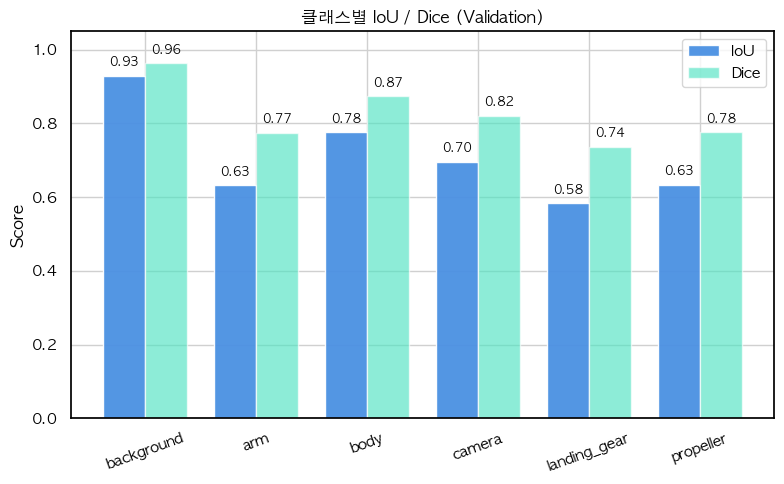

✅ 저장: outputs/report/val_class_iou_dice.png


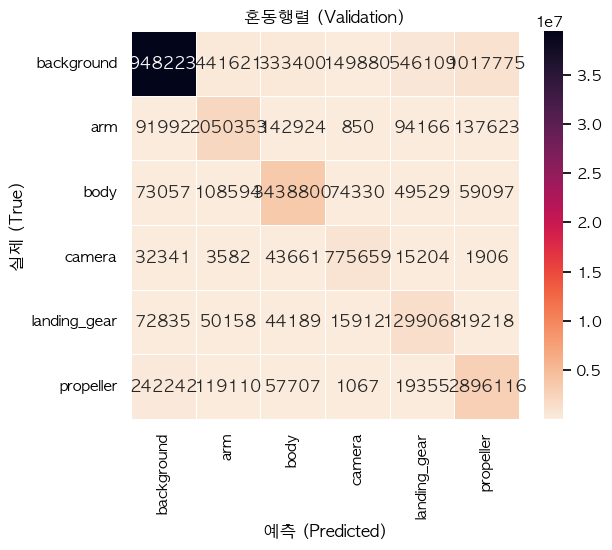

✅ 저장: outputs/report/val_confusion_matrix.png


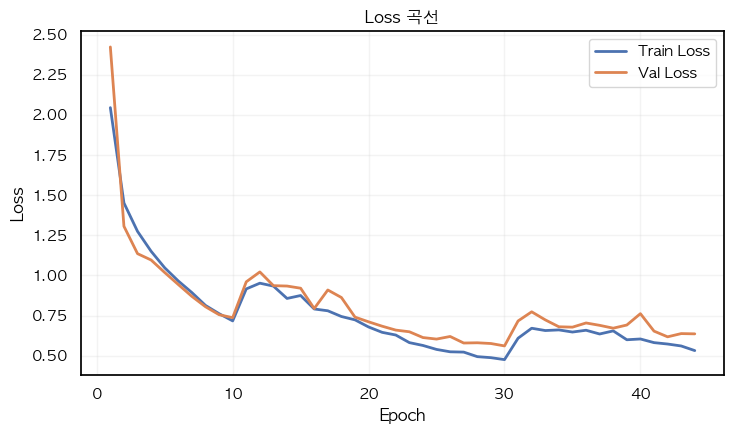

✅ 저장: outputs/report/curve_loss.png


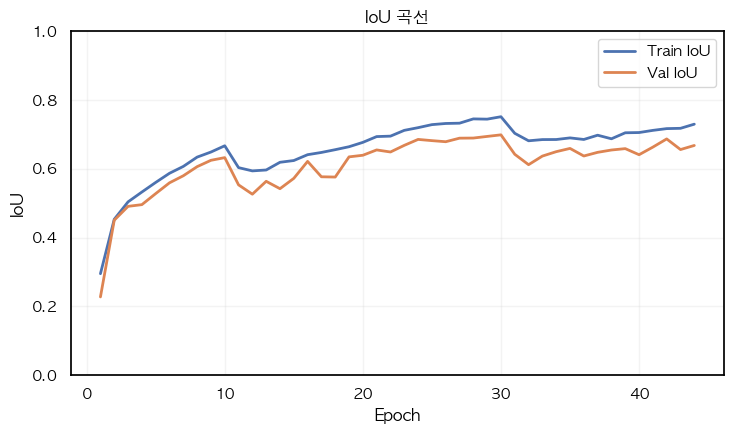

✅ 저장: outputs/report/curve_iou.png


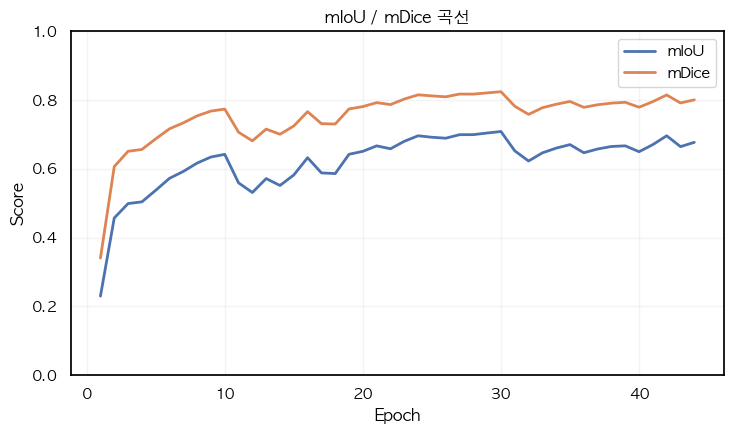

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


✅ 저장: outputs/report/curve_miou_mdice.png


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


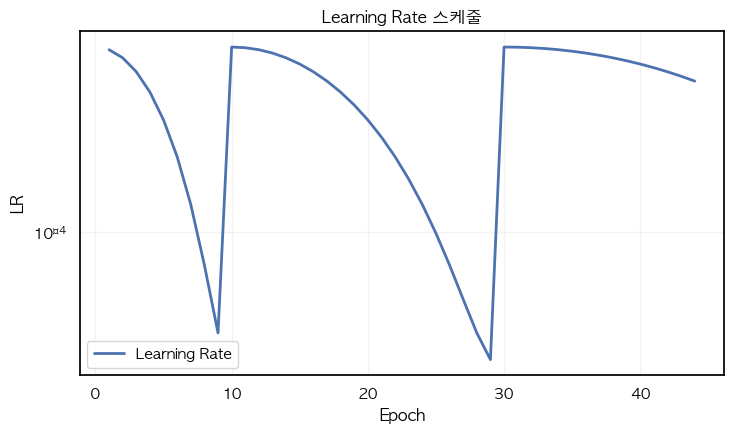

✅ 저장: outputs/report/curve_lr.png

🎉 리포트 이미지 생성 완료!
📂 저장 폴더: outputs/report


In [90]:
# ==============================================================
# 📈 최종 리포트: 지표 요약 + 클래스별 그래프 + 혼동행렬 + (옵션)학습곡선
# ==============================================================

import os, json, platform
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib as mpl
import seaborn as sns
import torch

# ---------- 경로 설정 ----------
OUT_DIR = Path("./outputs")
REPORT_DIR = OUT_DIR / "report"
REPORT_DIR.mkdir(parents=True, exist_ok=True)
CKPT_PATH = OUT_DIR / "final_model.pth"
HIST_PATH = REPORT_DIR / "history2.json"


# ---------- 스타일 ----------
sns.set_theme(style="whitegrid", context="notebook")
BAR_COLORS = ["#4A90E2", "#50E3C2"]  # IoU, Dice
CMAP_CM = "rocket_r"                 # 혼동행렬 컬러맵
ALPHA_IoU, ALPHA_Dice = 0.95, 0.65



font_list = [font.name for font in fm.fontManager.ttflist]
plt.rcParams['font.family'] = 'AppleGothic' # MacOS

mpl.rcParams.update({
    "axes.unicode_minus": False,
    "pdf.fonttype": 42,    # 폰트 임베딩 호환
    "ps.fonttype": 42,

    # 밝은 배경/텍스트 컬러
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "black",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "text.color": "black",
    "axes.titlecolor": "black",
    "grid.color": "#D0D0D0",
})



# ---------- 체크포인트 로드 ----------
if not CKPT_PATH.exists():
    raise FileNotFoundError(f"❌ 체크포인트가 없습니다: {CKPT_PATH}")

ckpt = torch.load(CKPT_PATH, map_location="cpu")
if "val_metrics" not in ckpt:
    raise ValueError("❌ best_model_v2.pth에 'val_metrics'가 없습니다. 지표 저장 버전으로 학습했는지 확인하세요.")

metrics = ckpt["val_metrics"]
classes = ckpt.get("class_names", [f"class_{i}" for i in range(len(metrics["IoU_per_class"]))])

# ---------- 숫자 지표 출력 ----------
train_loss = ckpt.get("train_loss", None)
val_loss   = ckpt.get("val_loss", None)
train_iou  = ckpt.get("train_iou", None)
val_iou    = ckpt.get("val_iou", None)

print("============================================================")
print("📊 드론 부품 세그멘테이션 최종 성능 리포트")
print("============================================================")
print(f"🧩 Best Epoch:  {ckpt.get('epoch','?')}")
if train_loss is not None and train_iou is not None:
    print(f"🔹 Train Loss:  {train_loss:.4f} | IoU: {train_iou:.4f}")
if val_loss is not None and val_iou is not None:
    print(f"🔹 Val   Loss:  {val_loss:.4f} | IoU: {val_iou:.4f}")
print("------------------------------------------------------------")
print(f"🔸 mIoU:        {metrics['mIoU']:.4f}")
print(f"🔸 mDice:       {metrics['mDice']:.4f}")
print(f"🔸 PixelAcc:    {metrics['PixelAcc']:.4f}")
print(f"🔸 FWIoU:       {metrics['FWIoU']:.4f}")
print("------------------------------------------------------------")

# ---------- 클래스별 IoU/Dice 바차트 ----------
iou_per_class  = np.array(metrics["IoU_per_class"])
dice_per_class = np.array(metrics["Dice_per_class"])

plt.figure(figsize=(max(8, len(classes)*1.1), 5))
x = np.arange(len(classes))
w = 0.38
plt.bar(x - w/2, iou_per_class, width=w, color=BAR_COLORS[0], alpha=ALPHA_IoU, label="IoU")
plt.bar(x + w/2, dice_per_class, width=w, color=BAR_COLORS[1], alpha=ALPHA_Dice, label="Dice")
for i, v in enumerate(iou_per_class):
    plt.text(i - w/2, v + 0.02, f"{v:.2f}", ha="center", va="bottom", fontsize=9)
for i, v in enumerate(dice_per_class):
    plt.text(i + w/2, v + 0.02, f"{v:.2f}", ha="center", va="bottom", fontsize=9)
plt.xticks(x, classes, rotation=20)
plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.title("클래스별 IoU / Dice (Validation)")
plt.legend()
plt.tight_layout()
save_path = REPORT_DIR / "val_class_iou_dice.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ 저장: {save_path}")

# ---------- 혼동행렬(Confusion Matrix) ----------
confmat = np.array(metrics["confusion_matrix"])
plt.figure(figsize=(6.5, 5.5))
sns.heatmap(confmat, annot=True, fmt="d", cmap=CMAP_CM,
            xticklabels=classes, yticklabels=classes, cbar=True,
            linewidths=.5, linecolor="white", square=True)
plt.xlabel("예측 (Predicted)")
plt.ylabel("실제 (True)")
plt.title("혼동행렬 (Validation)")
plt.tight_layout()
save_path = REPORT_DIR / "val_confusion_matrix.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ 저장: {save_path}")

# ---------- (옵션) 학습곡선: history.json 있으면 그리기 ----------
if HIST_PATH.exists():
    try:
        with open(HIST_PATH, "r") as f:
            H = json.load(f)
        # 존재 확인
        has_loss = len(H.get("train_loss", [])) > 0 and len(H.get("val_loss", [])) > 0
        has_iou  = len(H.get("train_iou", [])) > 0 and len(H.get("val_iou", [])) > 0
        has_meta = len(H.get("mIoU", [])) > 0 and len(H.get("mDice", [])) > 0
        has_lr   = len(H.get("lr", [])) > 0

        epochs = H.get("epoch", list(range(1, max(
            len(H.get("train_loss", [])),
            len(H.get("val_loss", [])),
            len(H.get("train_iou", [])),
            len(H.get("val_iou", [])),
            len(H.get("mIoU", [])),
            len(H.get("mDice", [])),
            len(H.get("lr", []))
        )+1)))

        # 1) Loss 곡선
        if has_loss:
            plt.figure(figsize=(7.5,4.5))
            plt.plot(epochs, H["train_loss"], label="Train Loss", lw=2)
            plt.plot(epochs, H["val_loss"],   label="Val Loss",   lw=2)
            plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Loss 곡선")
            plt.legend(); plt.grid(True, alpha=.25)
            plt.tight_layout()
            p = REPORT_DIR / "curve_loss.png"; plt.savefig(p, dpi=150, bbox_inches="tight"); plt.show()
            print(f"✅ 저장: {p}")

        # 2) IoU 곡선
        if has_iou:
            plt.figure(figsize=(7.5,4.5))
            plt.plot(epochs, H["train_iou"], label="Train IoU", lw=2)
            plt.plot(epochs, H["val_iou"],   label="Val IoU",   lw=2)
            plt.xlabel("Epoch"); plt.ylabel("IoU"); plt.title("IoU 곡선")
            plt.ylim(0, 1.0)
            plt.legend(); plt.grid(True, alpha=.25)
            plt.tight_layout()
            p = REPORT_DIR / "curve_iou.png"; plt.savefig(p, dpi=150, bbox_inches="tight"); plt.show()
            print(f"✅ 저장: {p}")

        # 3) mIoU / mDice 곡선
        if has_meta:
            plt.figure(figsize=(7.5,4.5))
            plt.plot(epochs, H["mIoU"],  label="mIoU",  lw=2)
            plt.plot(epochs, H["mDice"], label="mDice", lw=2)
            plt.xlabel("Epoch"); plt.ylabel("Score"); plt.title("mIoU / mDice 곡선")
            plt.ylim(0, 1.0)
            plt.legend(); plt.grid(True, alpha=.25)
            plt.tight_layout()
            p = REPORT_DIR / "curve_miou_mdice.png"; plt.savefig(p, dpi=150, bbox_inches="tight"); plt.show()
            print(f"✅ 저장: {p}")

        # 4) LR 곡선
        if has_lr:
            plt.figure(figsize=(7.5,4.5))
            plt.plot(epochs, H["lr"], label="Learning Rate", lw=2)
            plt.xlabel("Epoch"); plt.ylabel("LR"); plt.title("Learning Rate 스케줄")
            plt.yscale("log")
            plt.legend(); plt.grid(True, alpha=.25)
            plt.tight_layout()
            p = REPORT_DIR / "curve_lr.png"; plt.savefig(p, dpi=150, bbox_inches="tight"); plt.show()
            print(f"✅ 저장: {p}")

        if not (has_loss or has_iou or has_meta or has_lr):
            print("ℹ️ history.json은 있지만 시각화할 키가 비어있습니다.")

    except Exception as e:
        print(f"⚠️ history.json을 읽는 중 문제가 발생했습니다: {e}")
else:
    print("ℹ️ history.json이 없어 학습곡선은 건너뜁니다. (지표/혼동행렬은 정상 저장)")

print("\n🎉 리포트 이미지 생성 완료!")
print(f"📂 저장 폴더: {REPORT_DIR}")


## ✅ 팁
- `DATA_ROOT`만 실제 경로로 바꾸면 바로 학습이 시작됩니다.
- **개선이 느리면**
  - `ETA_MIN = 3e-5 → 5e-5`로 상향
  - `IMG_SIZE = 576` (메모리 허용 시)
  - CE:Dice = `1.0 : 1.3`로 Dice 비중 살짝 증가
  - 클래스 가중이 너무 크면 `[0.5, 2, 2, 3, 3, 3]` 정도로 완화
- Apple Silicon(MPS)에서는 `num_workers=0`, `pin_memory=False`가 안정적입니다.


In [15]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import platform

# 한글 폰트 설정
if platform.system() == "Darwin":  # macOS
    plt.rc("font", family="AppleGothic")
elif platform.system() == "Windows":  # Windows
    plt.rc("font", family="Malgun Gothic")
else:  # Linux (예: Colab)
    plt.rc("font", family="NanumGothic")

# 마이너스 기호 깨짐 방지
plt.rcParams["axes.unicode_minus"] = False

## 11. 새로운 이미지 예측 (Inference & Visualization)
학습된 모델(`best_model.pth`)을 사용해 새로운 드론 이미지를 세그멘테이션 예측  
예측 결과는 원본 이미지 위에 색상 마스크를 오버레이(Overlay)하여 시각화

- 입력: `new_image/` 폴더 내 테스트 이미지 (jpg/png 등)  
- 출력: `outputs/prediction_overlay.png`  
- 색상 팔레트는 학습 데이터와 동일하게 구성되어, 부품별 색상이 유지

예측 완료! 결과 저장: ./outputs/prediction_overlay.png


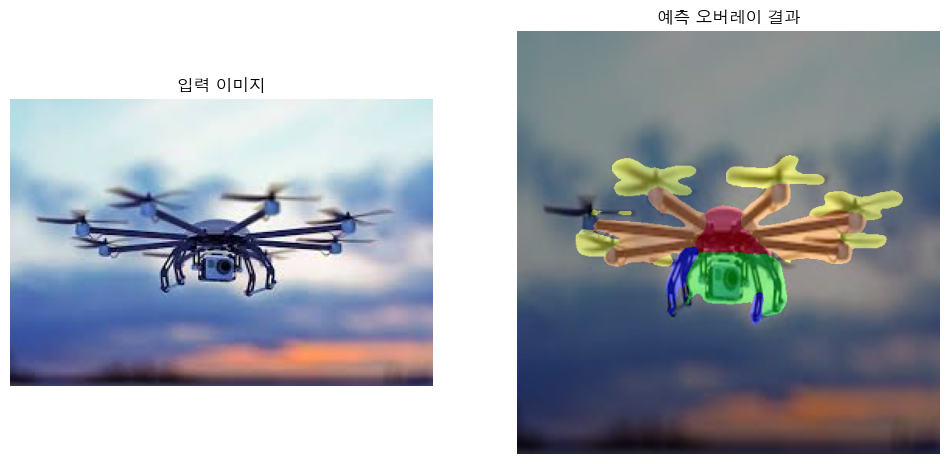

In [100]:
import torch, cv2, numpy as np
from pathlib import Path
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp
import matplotlib.pyplot as plt

# 설정
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_PATH = "./outputs/final_model.pth"   # 모델 경로
IMG_PATH = "./new_image/12.jpeg"              # 예측할 이미지 경로
OUT_PATH = "./outputs/prediction_overlay.png"

# 클래스 색상 팔레트 (dataset.py와 동일)
PALETTE = np.array([
    [0, 0, 0],         # background
    [255, 128, 0],     # arm
    [255, 0, 0],       # body
    [0, 255, 0],       # camera
    [0, 0, 255],       # landing_gear
    [255, 255, 0]      # propeller
], dtype=np.uint8)

# 전처리 transform (validation과 동일)
transform = A.Compose([
    A.Resize(512, 512),
    A.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

# 1. 이미지 로드
image = cv2.imread(IMG_PATH)
if image is None:
    raise FileNotFoundError(f"이미지를 찾을 수 없습니다: {IMG_PATH}")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
orig_size = image.shape[:2]

# 2. 전처리
tensor = transform(image=image)["image"].unsqueeze(0).to(DEVICE)

# 3. 모델 불러오기
model = smp.Unet(encoder_name="vgg16_bn", encoder_weights=None, in_channels=3, classes=6)
ckpt = torch.load(MODEL_PATH, map_location=DEVICE)
model.load_state_dict(ckpt["model_state_dict"])
model.to(DEVICE)
model.eval()

# 4. 예측
with torch.no_grad():
    pred = model(tensor)
    mask = pred.argmax(1)[0].cpu().numpy().astype(np.uint8)

# 5. 시각화 (색상 오버레이)
mask_color = PALETTE[mask]
overlay = cv2.addWeighted(
    cv2.resize(image, (mask_color.shape[1], mask_color.shape[0])),
    0.6, mask_color, 0.4, 0
)

# 6. 결과 저장 및 출력
cv2.imwrite(OUT_PATH, cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR))
print(f"예측 완료! 결과 저장: {OUT_PATH}")

plt.figure(figsize=(12,6))
plt.subplot(1,2,1); plt.imshow(image); plt.title("입력 이미지"); plt.axis("off")
plt.subplot(1,2,2); plt.imshow(overlay); plt.title("예측 오버레이 결과"); plt.axis("off")
plt.show()

✅ Val samples: 206
✅ Model loaded on mps

📊 총괄 지표
 - mIoU: 0.7087
 - mDice(F1): 0.8244
 - Pixel Acc: 0.9248
 - FWIoU: 0.8731

📑 클래스별 지표
   class_id    class_name     IoU  Dice(F1)  Precision  Recall
0         0    background  0.9294    0.9634     0.9872  0.9407
1         1           arm  0.6326    0.7750     0.7393  0.8143
2         2          body  0.7771    0.8746     0.8469  0.9041
3         3        camera  0.6960    0.8208     0.7622  0.8892
4         4  landing_gear  0.5837    0.7371     0.6420  0.8652
5         5     propeller  0.6336    0.7757     0.7009  0.8682

✅ 클래스별 지표 CSV 저장: outputs/report/metrics_val.csv


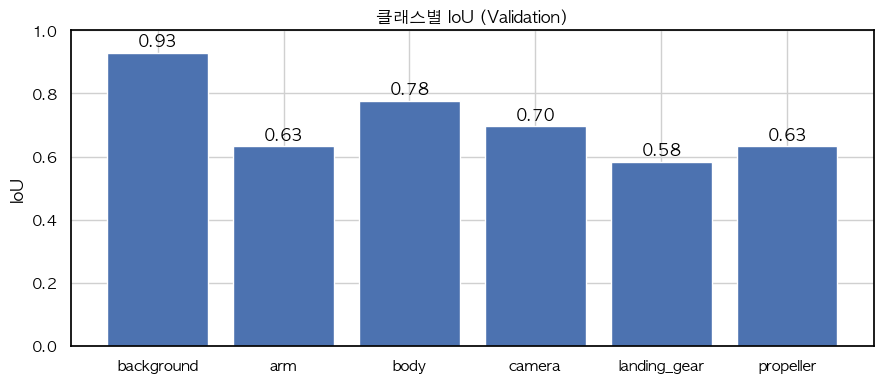

✅ IoU 막대그래프 저장: outputs/report/val_iou_bar.png


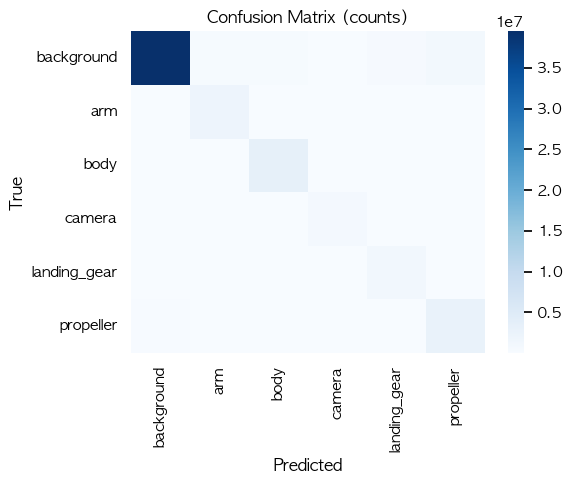

✅ 혼동행렬 저장: outputs/report/confusion_matrix_counts.png


In [88]:
# ============================
# 드론 부품 세그멘테이션 평가 스크립트
# ============================
import os, sys, json, math, platform
from pathlib import Path
import numpy as np
import torch
from torch.utils.data import DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp
import matplotlib.pyplot as plt
import pandas as pd

# ---------- 환경/경로 ----------
DEVICE = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
NUM_CLASSES = 6
CLASS_NAMES = ["background", "arm", "body", "camera", "landing_gear", "propeller"]

# (필요 시 수정) 데이터 경로
VAL_IMAGES = "./data/val/images"
VAL_MASKS  = "./data/val/masks"

# (필요 시 수정) 체크포인트 경로
CKPT_PATH = "./outputs/final_model.pth"

# 출력 폴더
OUT_DIR = Path("./outputs/report")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ---------- 한글 폰트(그래프 깨짐 방지) ----------
import matplotlib
if platform.system() == "Darwin":      # macOS
    plt.rc("font", family="AppleGothic")
elif platform.system() == "Windows":   # Windows
    plt.rc("font", family="Malgun Gothic")
else:                                  # Linux/Colab
    plt.rc("font", family="NanumGothic")
plt.rcParams["axes.unicode_minus"] = False

# ---------- 전처리 (검증과 동일) ----------
def get_val_transform(image_size=512):
    return A.Compose([
        A.Resize(image_size, image_size),
        A.Normalize(mean=[0.485, 0.456, 0.406],
                    std=[0.229, 0.224, 0.225]),
        ToTensorV2(),
    ])

VAL_TF = get_val_transform(512)

# ---------- DroneDataset (필요 시 내장) ----------
# 이미 프로젝트에 dataset.py가 있다면 다음 3줄로 대체:
# from dataset import DroneDataset, get_val_transform
# VAL_TF = get_val_transform(512)
# (아래 임시 Dataset은 dataset.py가 없을 때만 사용)
class DroneDataset(torch.utils.data.Dataset):
    def __init__(self, images_dir, masks_dir, transform=None):
        self.images_dir = Path(images_dir)
        self.masks_dir  = Path(masks_dir)
        self.transform = transform
        self.rgb_to_class = {
            (0, 0, 0): 0,           # background
            (255, 128, 0): 1,       # arm
            (255, 0, 0): 2,         # body
            (0, 255, 0): 3,         # camera
            (0, 0, 255): 4,         # landing_gear
            (255, 255, 0): 5        # propeller
        }
        self.image_files = sorted([p for p in self.images_dir.glob("*") if p.suffix.lower() in [".jpg",".jpeg",".png"]])
        self.image_files = [p for p in self.image_files if (self.masks_dir / f"{p.stem}.png").exists()]

    def __len__(self):
        return len(self.image_files)

    def _rgb_to_class_mask(self, mask_rgb):
        h, w = mask_rgb.shape[:2]
        mask = np.zeros((h, w), dtype=np.uint8)
        r, g, b = mask_rgb[:,:,0], mask_rgb[:,:,1], mask_rgb[:,:,2]
        for (R,G,B), cid in self.rgb_to_class.items():
            match = (r==R) & (g==G) & (b==B)
            mask[match] = cid
        return mask

    def __getitem__(self, idx):
        import cv2
        img_path = self.image_files[idx]
        image = cv2.imread(str(img_path))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask_path = self.masks_dir / f"{img_path.stem}.png"
        mask_rgb = cv2.imread(str(mask_path))
        if mask_rgb is None:
            raise FileNotFoundError(f"Mask not found: {mask_path}")
        mask_rgb = cv2.cvtColor(mask_rgb, cv2.COLOR_BGR2RGB)

        mask = self._rgb_to_class_mask(mask_rgb)

        if self.transform is not None:
            out = self.transform(image=image, mask=mask)
            image = out["image"]
            mask  = out["mask"]

        return {"image": image, "mask": torch.as_tensor(mask, dtype=torch.long), "filename": img_path.name}

# ---------- 데이터로더 ----------
val_ds = DroneDataset(VAL_IMAGES, VAL_MASKS, transform=VAL_TF)
val_loader = DataLoader(val_ds, batch_size=4, shuffle=False, num_workers=0, pin_memory=False)

print(f"✅ Val samples: {len(val_ds)}")

# ---------- 모델 로드 ----------
def load_model(ckpt_path: str):
    model = smp.Unet(encoder_name="vgg16_bn", encoder_weights=None, in_channels=3, classes=NUM_CLASSES)
    ckpt = torch.load(ckpt_path, map_location="cpu")
    state = ckpt.get("model_state_dict", None) or ckpt.get("state_dict", None) or ckpt
    model.load_state_dict(state)
    model.to(DEVICE)
    model.eval()
    return model

if not Path(CKPT_PATH).exists():
    raise FileNotFoundError(f"체크포인트가 없습니다: {CKPT_PATH}")

model = load_model(CKPT_PATH)
print(f"✅ Model loaded on {DEVICE}")

# ---------- Confusion Matrix Utils ----------
def fast_confusion_matrix(y_true, y_pred, num_classes):
    """
    y_true/y_pred: (H, W) numpy arrays with values in [0, num_classes-1]
    """
    mask = (y_true >= 0) & (y_true < num_classes)
    hist = np.bincount(
        num_classes * y_true[mask].astype(int) + y_pred[mask].astype(int),
        minlength=num_classes ** 2
    ).reshape(num_classes, num_classes)
    return hist

def compute_metrics_from_hist(hist):
    """
    hist: (C, C)
    returns: dicts of per-class metrics + aggregates
    """
    # IoU = TP / (TP + FP + FN)
    tp = np.diag(hist)
    fp = hist.sum(axis=0) - tp
    fn = hist.sum(axis=1) - tp
    denom_iou = (tp + fp + fn)
    iou = np.divide(tp, denom_iou, out=np.zeros_like(tp, dtype=float), where=denom_iou!=0)

    # Precision/Recall
    prec = np.divide(tp, (tp + fp), out=np.zeros_like(tp, dtype=float), where=(tp+fp)!=0)
    rec  = np.divide(tp, (tp + fn), out=np.zeros_like(tp, dtype=float), where=(tp+fn)!=0)

    # Dice (F1) = 2TP / (2TP + FP + FN)
    denom_dice = (2*tp + fp + fn)
    dice = np.divide(2*tp, denom_dice, out=np.zeros_like(tp, dtype=float), where=denom_dice!=0)

    # Aggregates
    miou = np.nanmean(iou)
    mdice = np.nanmean(dice)

    # Pixel accuracy
    pixel_acc = tp.sum() / hist.sum() if hist.sum() > 0 else 0.0

    # Frequency Weighted IoU
    freq = hist.sum(axis=1) / hist.sum() if hist.sum() > 0 else np.zeros_like(tp, dtype=float)
    fwiou = (freq * iou).sum()

    return {
        "iou_per_class": iou,
        "precision_per_class": prec,
        "recall_per_class": rec,
        "dice_per_class": dice,
        "miou": miou,
        "mdice": mdice,
        "pixel_acc": pixel_acc,
        "fwiou": fwiou
    }

# ---------- 평가 루프 ----------
hist_total = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=np.int64)

with torch.no_grad():
    for batch in val_loader:
        images = batch["image"].to(DEVICE)
        masks  = batch["mask"].numpy()  # (B, H, W) on CPU numpy for hist

        logits = model(images)              # (B, C, H, W)
        preds = logits.argmax(1).cpu().numpy()

        for yt, yp in zip(masks, preds):
            hist_total += fast_confusion_matrix(yt, yp, NUM_CLASSES)

# ---------- 메트릭 계산 ----------
metrics = compute_metrics_from_hist(hist_total)
iou, prec, rec, dice = metrics["iou_per_class"], metrics["precision_per_class"], metrics["recall_per_class"], metrics["dice_per_class"]

summary = {
    "mIoU": metrics["miou"],
    "mDice(F1)": metrics["mdice"],
    "Pixel Acc": metrics["pixel_acc"],
    "FWIoU": metrics["fwiou"]
}

print("\n📊 총괄 지표")
for k, v in summary.items():
    print(f" - {k}: {v:.4f}")

print("\n📑 클래스별 지표")
df = pd.DataFrame({
    "class_id": list(range(NUM_CLASSES)),
    "class_name": CLASS_NAMES,
    "IoU": np.round(iou, 4),
    "Dice(F1)": np.round(dice, 4),
    "Precision": np.round(prec, 4),
    "Recall": np.round(rec, 4),
})
print(df)

# 저장
csv_path = OUT_DIR / "metrics_val.csv"
df.to_csv(csv_path, index=False)
print(f"\n✅ 클래스별 지표 CSV 저장: {csv_path}")

# ---------- 시각화 (클래스별 IoU) ----------
plt.figure(figsize=(9,4))
plt.bar(CLASS_NAMES, iou)
plt.title("클래스별 IoU (Validation)")
plt.ylabel("IoU")
plt.ylim(0, 1.0)
for i, v in enumerate(iou):
    plt.text(i, v+0.02, f"{v:.2f}", ha="center")
plt.tight_layout()
plt.savefig(OUT_DIR / "val_iou_bar.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ IoU 막대그래프 저장: {OUT_DIR/'val_iou_bar.png'}")

# ---------- 혼동행렬 저장 (선택) ----------
import seaborn as sns
plt.figure(figsize=(6,5))
import matplotlib
sns.heatmap(hist_total, annot=False, cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (counts)")
plt.tight_layout()
plt.savefig(OUT_DIR / "confusion_matrix_counts.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ 혼동행렬 저장: {OUT_DIR/'confusion_matrix_counts.png'}")

In [ ]:
import matplotlib.pyplot as plt
from matplotlib import colors
import numpy as np

# 전역 스타일(라이트 테마)
plt.style.use("seaborn-v0_8-whitegrid")  # 라이트/깔끔
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.labelsize": 12,
    "axes.titlesize": 14,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.titlepad": 10,
    "axes.grid": True,
    "grid.linestyle": "--",
    "grid.alpha": 0.3,
})

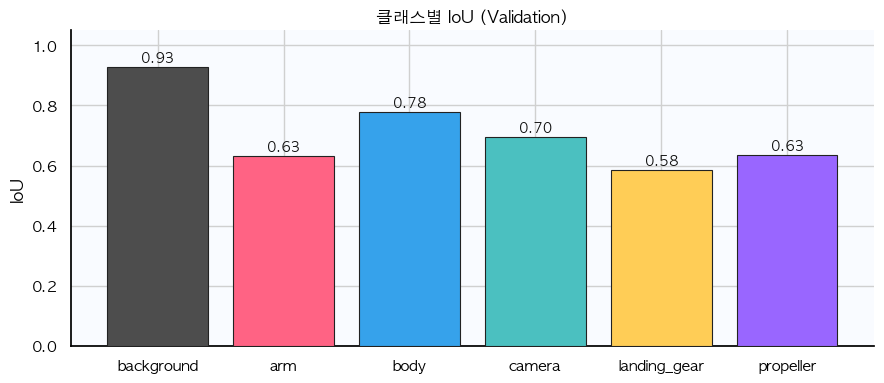

✅ IoU 막대그래프 저장(예쁜 버전): outputs/report/val_iou_bar.png


In [89]:
import matplotlib
if platform.system() == "Darwin":      # macOS
    plt.rc("font", family="AppleGothic")
elif platform.system() == "Windows":   # Windows
    plt.rc("font", family="Malgun Gothic")
else:                                  # Linux/Colab
    plt.rc("font", family="NanumGothic")
plt.rcParams["axes.unicode_minus"] = False

# segmentation 팔레트(0~255) → matplotlib(0~1)
PALETTE_255 = np.array([
    [0, 0, 0],        # background (표시용이 아니라 검정이니 바 차트에서는 다른 색을 주자)
    [255, 99, 132],   # arm
    [54, 162, 235],   # body
    [75, 192, 192],   # camera
    [255, 205, 86],   # landing_gear
    [153, 102, 255],  # propeller
], dtype=np.uint8)
PALETTE = (PALETTE_255 / 255.0).tolist()

# background는 차트에서 너무 어두우니 조금 밝게 보정
bar_colors = PALETTE.copy()
bar_colors[0] = (0.3, 0.3, 0.3)   # background 막대 색 살짝 밝게

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(CLASS_NAMES, iou, color=bar_colors, edgecolor="#222", linewidth=0.8, zorder=3)

# 막대 위에 value label
for rect, v in zip(bars, iou):
    ax.text(rect.get_x() + rect.get_width()/2, v + 0.03, f"{v:.2f}",
            ha="center", va="center", fontsize=10, color="#111", zorder=4)

# y축 범위/눈금
ax.set_ylim(0, 1.05)
ax.set_ylabel("IoU")
ax.set_title("클래스별 IoU (Validation)")

# 바닥 음영(가벼운 highlight)
ax.patch.set_facecolor("#f9fbff")
ax.patch.set_alpha(0.9)

# 상단/우측 스파인 제거 → 깨끗
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

fig.tight_layout()
fig.savefig(OUT_DIR / "val_iou_bar.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ IoU 막대그래프 저장(예쁜 버전): {OUT_DIR/'val_iou_bar.png'}")